# Sphero BOLT+ — Sim2Real Validation

Validates fixed optimal parameters against recordings with a specific steady-command duration.
Run with a different `DATA_DIR` / `STEADY_S` to validate a different dataset.

| Row        | Left                         | Right                     |
|------------|------------------------------|---------------------------|
| **Simple** | Final Distance (Real vs Sim) | Sim2Real Distance Gap %   |
| **Sapien** | Final Distance (Real vs Sim) | Sim2Real Distance Gap %   |

In [1]:
# ── Path setup ────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

_here = Path('__file__').resolve().parent
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))

# ── Imports ───────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

from utils.speed_data import load_all_runs
from utils.calib_data import df_to_run_metrics
from utils.calib_plot import _fill_distance_comparison, _fill_distance_gap, save_validation_figure
from utils.speed_plot import plot_single_speed_with_sim, plot_all_distance_with_sim_subplots

print('Imports OK')

[2026-05-21 21:22:40.599] WARNING  - rlive_sim.engine.sapien.world_loading.py:31 - ⚠️ Pinocchio not found. Patching SAPIEN PinocchioModel to prevent Viewer crashes.
Imports OK


C:\Users\kilia\Documents\GitHub\ReLoop_RLive\.venv\Lib\site-packages\sapien\wrapper\pinocchio_model.py:299: UserWarning: pinnochio package is not installed, robotics functionalities will not be available
  warnings.warn(


In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║                   ── CONFIG CELL ──                          ║
# ║  Edit here only.  All other cells run without changes.       ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Optimal parameters ────────────────────────────────────────────────────────
# Simple: one linear factor — final_dist = BEST_SIMPLE × speed_cmd × steady_s
BEST_SIMPLE = 0.00713   # m s⁻¹ per speed_cmd unit

# Sapien: trapezoidal velocity profile with two physics params
BEST_SAPIEN = {
    'max_speed_ms':  1.83,
    'max_accel_ms2': 0.58,
}

# ── Validation dataset ────────────────────────────────────────────────────────
DATA_DIR = 'csv_files/data_1s'   # directory with exp_speed_*.csv files
STEADY_S = 1.0                   # command duration used during this recording (s)
SELECTED_SPEED = 150

# ── Signal preprocessing (keep identical to physic_sim2real.ipynb) ────────────
REDUCTION_MODE = 'center'
WINDOW         = 1
SMOOTH_WINDOW  = 1

# ── Output directory ──────────────────────────────────────────────────────────
DATA_OUTPUT = Path('./output')
DATA_OUTPUT.mkdir(exist_ok=True)

# ── Plot appearance — validation bar/line figures (Fig 1–4) ──────────────────
FIGSIZE  = (6, 4)   # (width, height) in inches
FONTSIZE = 12       # base font size for axis labels, ticks, legend
DPI      = 300      # rasterisation DPI for data layers inside the PDF

# ── Plot appearance — sim vs real trace figures (Fig 5–6) ─────────────────────
TRACE_FIGSIZE      = (10, 9)   # single-speed 3-panel trace
TRACE_FONTSIZE     = 11
GRID_SUBPLOT_SIZE  = (10, 9)  # (width, height) per subplot cell in the grid
GRID_FONTSIZE      = 10

print('Config OK')
print(f'  Simple  → factor = {BEST_SIMPLE} m s⁻¹ / cmd')
print(f'  Sapien  → max_speed={BEST_SAPIEN["max_speed_ms"]} m/s,  max_accel={BEST_SAPIEN["max_accel_ms2"]} m/s²')
print(f'  Dataset : {DATA_DIR}  (steady_s={STEADY_S} s)')

Config OK
  Simple  → factor = 0.00713 m s⁻¹ / cmd
  Sapien  → max_speed=1.83 m/s,  max_accel=0.58 m/s²
  Dataset : csv_files/data_1s  (steady_s=1.0 s)


In [3]:
# ── Load data ─────────────────────────────────────────────────────────────────
runs_df = load_all_runs(DATA_DIR, reduction_mode=REDUCTION_MODE, window=WINDOW)
runs_metrics = [
    df_to_run_metrics(df, speed_cmd, smooth_window=SMOOTH_WINDOW)
    for speed_cmd, df in sorted(runs_df.items())
]

speed_cmds = [r.speed_cmd for r in runs_metrics]
real_dists = [r.real_final_dist for r in runs_metrics]

print(f'Speed commands : {speed_cmds}')
print(f'Real distances : {[round(d, 3) for d in real_dists]}')

Loaded 6 runs from csv_files\data_1s
Speed commands : [25, 50, 75, 100, 125, 150]
Real distances : [0.061, 0.231, 0.357, 0.432, 0.636, 0.732]


## Sapien Engine
Created once here, closed in the last cell.

In [4]:
from utils.calib_sapien import make_simulate_fn

sapien_sim_fn = make_simulate_fn()
print('Sapien engine ready')

Sapien engine ready


## Simulation & Plots

Saved → output\val_data_1s_simple_distance.pdf


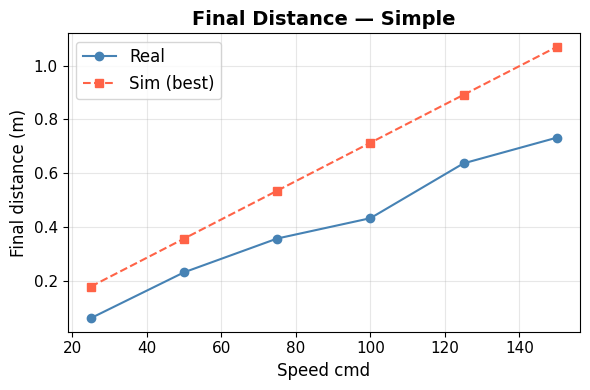

Saved → output\val_data_1s_simple_gap.pdf


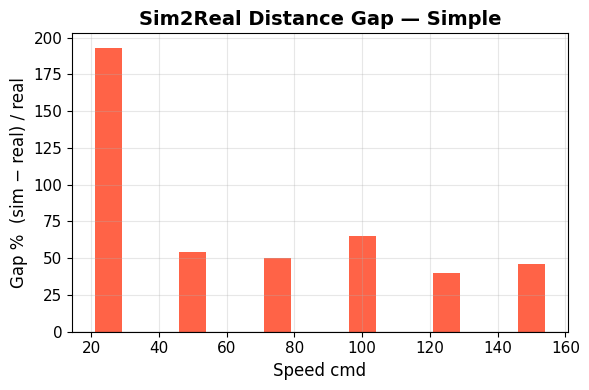

Saved → output\val_data_1s_sapien_distance.pdf


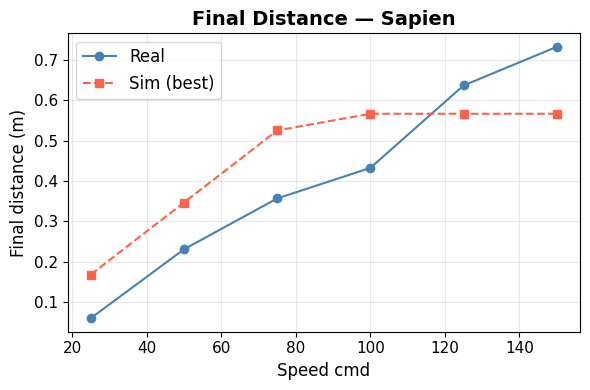

Saved → output\val_data_1s_sapien_gap.pdf


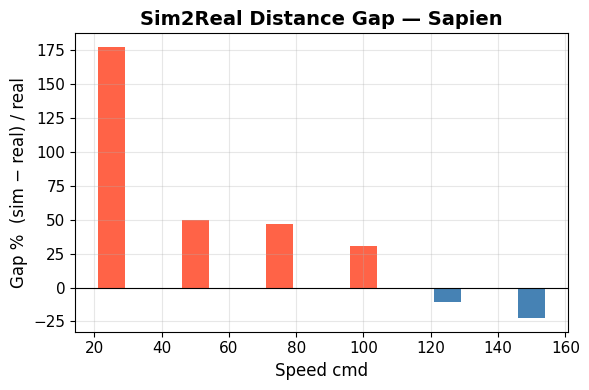

Saved 4 figures to output


In [5]:
# ── Simple: linear model ──────────────────────────────────────────────────────
# dist = factor × speed_cmd × steady_s  (instantaneous velocity, no ramp)
sim_dists_simple = [BEST_SIMPLE * r.speed_cmd * STEADY_S for r in runs_metrics]

# ── Sapien: full trapezoidal physics ──────────────────────────────────────────
sim_dists_sapien = [
    sapien_sim_fn(r.speed_cmd, STEADY_S,
                  BEST_SAPIEN['max_speed_ms'],
                  BEST_SAPIEN['max_accel_ms2'])['final_distance']
    for r in runs_metrics
]

label = Path(DATA_DIR).name   # e.g. "data_1s"

# ── Figure 1 : Final Distance — Simple ───────────────────────────────────────
save_validation_figure(_fill_distance_comparison,
    (speed_cmds, real_dists, sim_dists_simple),
    title='Final Distance — Simple',
    out_path=DATA_OUTPUT / f'val_{label}_simple_distance.pdf',
    figsize=FIGSIZE, fontsize=FONTSIZE, dpi=DPI)

# ── Figure 2 : Sim2Real Distance Gap — Simple ─────────────────────────────────
save_validation_figure(_fill_distance_gap,
    (speed_cmds, real_dists, sim_dists_simple),
    title='Sim2Real Distance Gap — Simple',
    out_path=DATA_OUTPUT / f'val_{label}_simple_gap.pdf',
    figsize=FIGSIZE, fontsize=FONTSIZE, dpi=DPI)

# ── Figure 3 : Final Distance — Sapien ───────────────────────────────────────
save_validation_figure(_fill_distance_comparison,
    (speed_cmds, real_dists, sim_dists_sapien),
    title='Final Distance — Sapien',
    out_path=DATA_OUTPUT / f'val_{label}_sapien_distance.pdf',
    figsize=FIGSIZE, fontsize=FONTSIZE, dpi=DPI)

# ── Figure 4 : Sim2Real Distance Gap — Sapien ────────────────────────────────
save_validation_figure(_fill_distance_gap,
    (speed_cmds, real_dists, sim_dists_sapien),
    title='Sim2Real Distance Gap — Sapien',
    out_path=DATA_OUTPUT / f'val_{label}_sapien_gap.pdf',
    figsize=FIGSIZE, fontsize=FONTSIZE, dpi=DPI)

print(f'Saved 4 figures to {DATA_OUTPUT}')

# SIM vs REAL

Saved → output\val_data_1s_speed150_trace.pdf


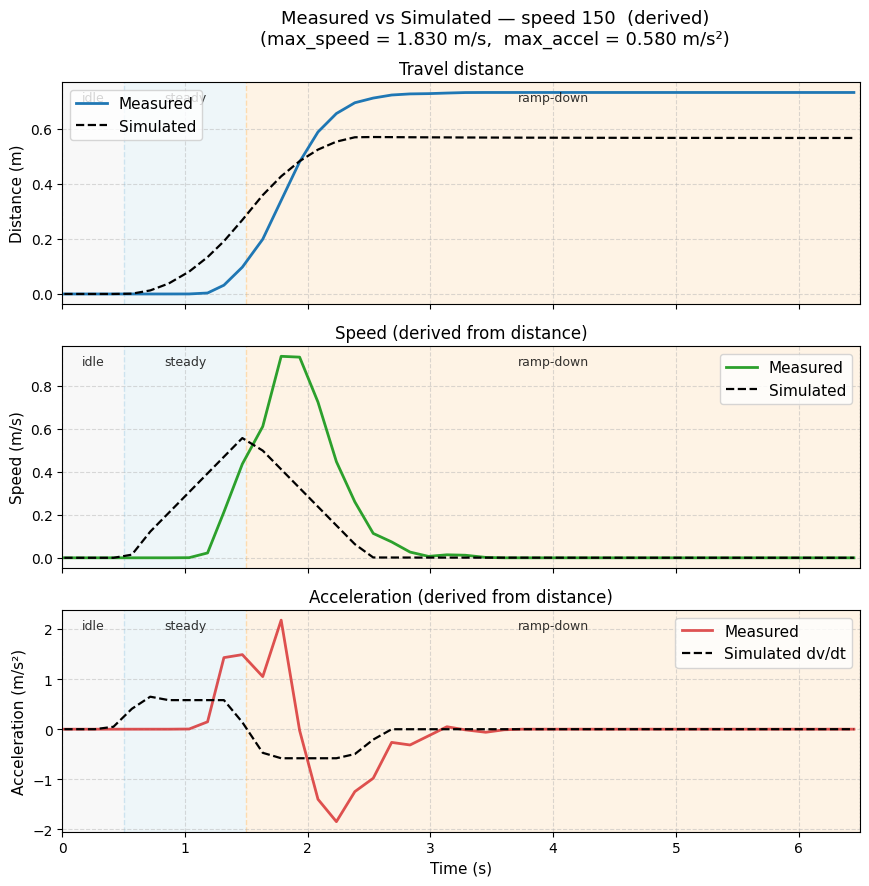

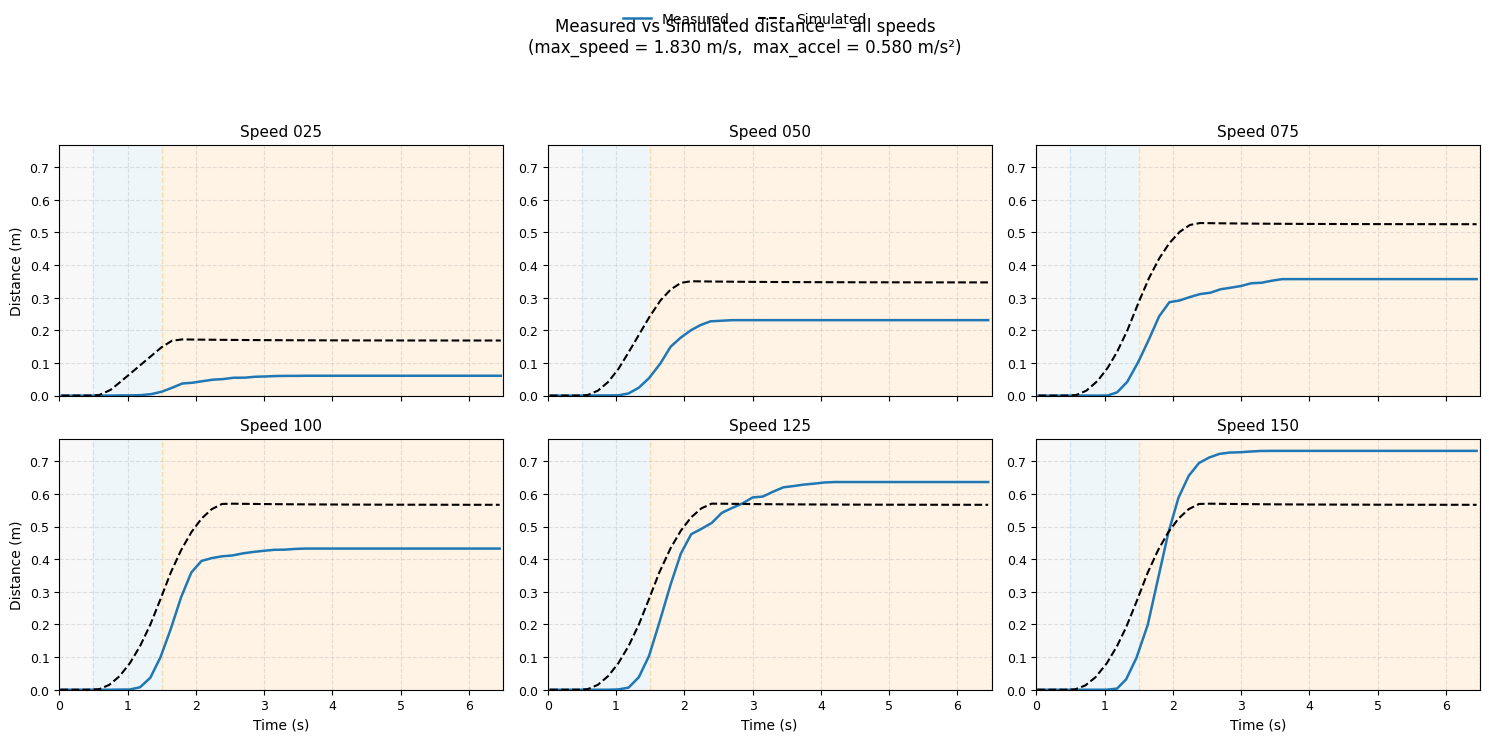

In [6]:
# Figure 5 : single speed trace
plot_single_speed_with_sim(
    SELECTED_SPEED, runs_df,
    BEST_SAPIEN['max_speed_ms'],
    BEST_SAPIEN['max_accel_ms2'],
    simulate_fn=sapien_sim_fn,
    duration_s=STEADY_S,
    show_delay=False,
    figsize=TRACE_FIGSIZE, fontsize=TRACE_FONTSIZE, dpi=DPI,
    save_path=DATA_OUTPUT / f'val_{label}_speed{SELECTED_SPEED}_trace.pdf',
)

# Figure 6 : all speeds distance grid
plot_all_distance_with_sim_subplots(
    runs_df,
    BEST_SAPIEN['max_speed_ms'],
    BEST_SAPIEN['max_accel_ms2'],
    cols=3, share_y=False,
    simulate_fn=sapien_sim_fn,
    duration_s=STEADY_S,
    #subplot_size=GRID_SUBPLOT_SIZE, fontsize=GRID_FONTSIZE, dpi=DPI,
    #save_path=DATA_OUTPUT / f'val_{label}_all_speeds_distance.pdf',
)

In [7]:
# ── Close Sapien engine when done ─────────────────────────────────────────────
#sapien_sim_fn.engine.close()
#print('Sapien engine closed.')

